# 60 TPD Melter

### Exploratory data analysis, features and insights, from 13 months of furnace data

**Furnace:** 60 TPD flint melter feeding lines S09, S10, S11 and S12 · **Scope:** melter natural gas, barrier boost and melter boost (forehearths excluded) · **Data:** 15-minute analytical record, 1 Sep 2025 – 30 Sep 2026, and the 1-minute crown thermocouple

---

**What this notebook answers**
1. **What does the furnace data look like?** How much data there is, how clean it is, and how each signal behaves over a day and over 13 months (*Part 1, Exploratory data analysis*, including the correlation heat map).
2. **Which measurements matter for energy, and how are they turned into model inputs?** (*Part 2, Features*.)
3. **What did we learn about where energy is used and lost?** Twelve findings, each with the evidence behind it (*Part 3, Insights*).
4. **How do these findings lower SFC?** What the recommended setpoints change, what they achieved on your own history, and the path to the 2% target (*Part 4*).

**How each section is written.** Every chart has the same four parts: *why we look at it*, *the chart*, *what we found*, and *what it means for SFC*. No prior knowledge of data science is needed; all terms are explained in section 0.1.

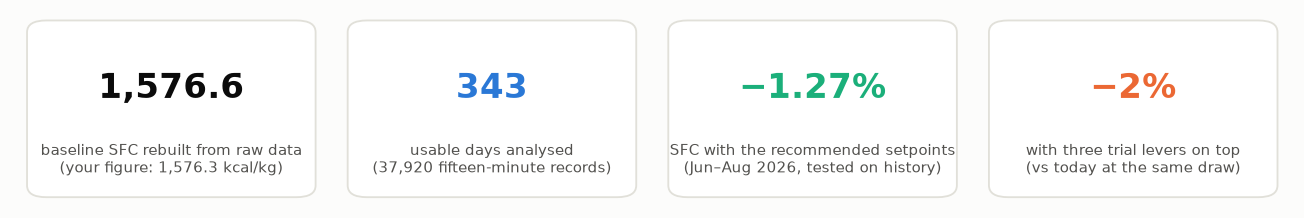

In [1]:
import report as R          # shared style, cleaned data and fair yardsticks
import eda_insights as E    # charts and tables for this notebook
R.setup()
D = R.Data()
R.kpi_tiles([('1,576.6', 'baseline SFC rebuilt from raw data\n(your figure: 1,576.3 kcal/kg)', R.INK),
             ('343', 'usable days analysed\n(37,920 fifteen-minute records)', R.BLUE),
             ('−1.27%', 'SFC with the recommended setpoints\n(Jun–Aug 2026, tested on history)', R.AQUA),
             ('−2%', 'with three trial levers on top\n(vs today at the same draw)', R.ORANGE)])

---
# Part 0. Before we start

## 0.1 Key terms

| Term | What it means in this notebook |
|---|---|
| **SFC** (specific fuel consumption) | Energy used to make one kg of glass, in kcal/kg. **Lower is better.** It is the number the 2% target applies to |
| **Draw** | Glass pulled from the furnace per day, in tonnes (t/day) |
| **NG** | Natural gas flow to the melter. One flow is set for both ports (common header), in SCM per 15 minutes, the same unit as your DCS and workbook |
| **NCV** (net calorific value) | Heat contained in one SCM of gas, in kcal/SCM. It changes during the day as the gas supply changes |
| **Gas heat** | NG × NCV: the heat actually delivered by the gas. Gcal = 1,000,000 kcal; Mcal = 1,000 kcal |
| **Secondary air** | Combustion air that enters with the gas through the firing port |
| **AFR** (air-fuel ratio) | Secondary air ÷ NG |
| **Air per Mcal** | Secondary air per Mcal of gas heat. It shows how much *excess* air is used, whatever the gas quality |
| **Barrier boost** | Electrodes low in the melter that heat the glass from below (kWh) |
| **Melter boost** | A second set of electrodes, run on a few fixed levels (kWh) |
| **MB3** | Bottom thermocouple 3: the temperature of the glass near the bottom (°C) |
| **Optical crown temperature** | Pyrometer reading of the crown (furnace roof), written down by hand every hour (°C) |
| **Crown thermocouple MC3** | A crown thermocouple logged by the DCS every minute (°C) |
| **Reversal** | The two ports swap roles every 20 minutes: one fires, the other takes the exhaust to its regenerator |
| **Usable day** | A day with a working NCV meter (≥ 90% valid readings), complete gas and boost data, and a draw value |
| **EDA** (exploratory data analysis) | Looking at the data before building any model: how much there is, how clean it is, and how the signals behave and relate |
| **Median, P5, P95** | The median is the middle day. P5 and P95 are a low and a high day: 5% of days are below P5, 5% above P95 |
| **Correlation** | A number from −1 to +1 that shows whether two signals move together (+), in opposite directions (−) or are unrelated (0). It shows association, not cause |
| **Feature** | A measured or calculated value that a model uses as an input, for example draw or furnace age |
| **Draw-adjusted %** | A day's energy compared with what the baseline period needed **at the same draw and cullet**. 0% = baseline performance, −2% = target |
| **Furnace ageing** | The slow loss of efficiency of refractory and regenerators: more energy is needed at the same draw as months pass |
| **Walk-forward test** | Each day is calculated using only the days *before* it, exactly as in live use |
| **Recommender** | A calculation that tells the operator what to set (NG, air, barrier boost) from current conditions |
| **Guard-rail** | A safety check that must hold while setpoints change (seeds, MB3, crown temperature) |

## 0.2 How the melter works, and where each measurement comes from
Gas and secondary air enter through the firing port and burn above the glass. The hot exhaust leaves through the opposite port and heats that port's regenerator, which then pre-heats the air when the ports swap 20 minutes later. Electrodes in the glass add electric heat from below. Three temperatures watch the process: two at the crown, one at the bottom.

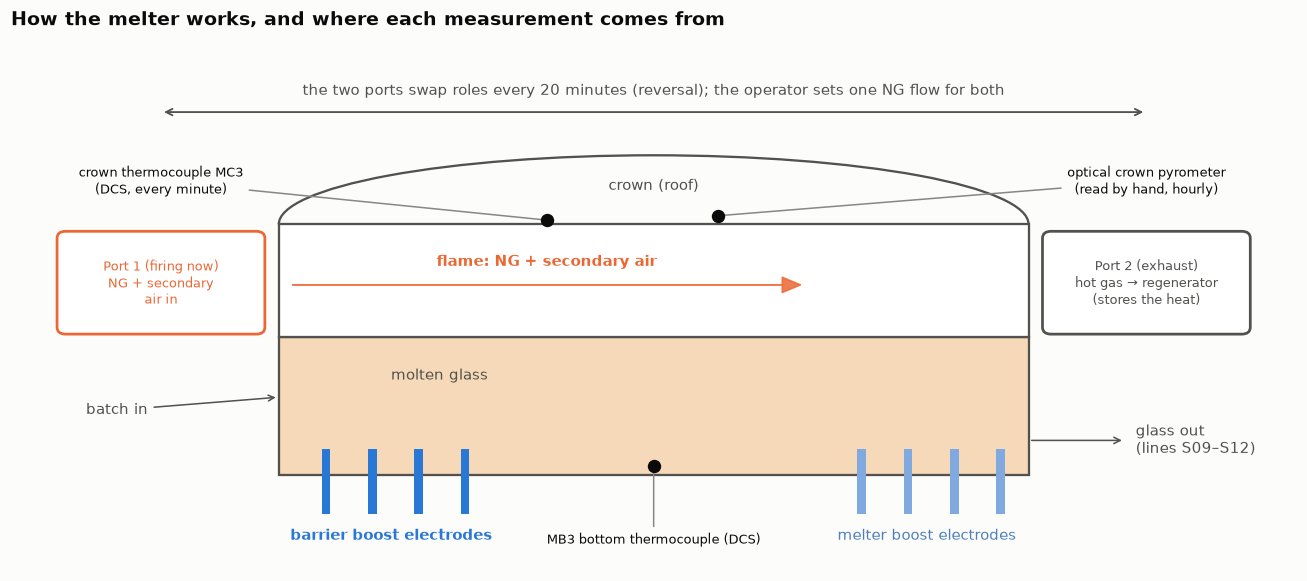

In [2]:
E.furnace_schematic()

**Why this matters for the analysis:** energy enters in two ways, gas from above and electricity from below. They do not have the same effect on the glass, so the analysis treats them separately and then adds them up in the SFC.

## 0.3 The SFC formula and the target
We use your formula exactly:

$$\text{SFC (kcal/kg)} = \frac{\sum (\text{NG} \times \text{NCV}) + (\sum \text{barrier kWh} + \sum \text{melter kWh}) \times 860}{\text{draw (kg)}} \quad \text{per day}$$

- NG × NCV is calculated **for every 15-minute interval**, with that interval's NCV, then added up over the day.
- 860 converts kWh of electricity into kcal.
- **Baseline:** 1 Sep 2025 – 31 Jul 2026, average **1,576.3 kcal/kg**. **Target:** −2%, i.e. **1,544.8 kcal/kg**, judged either within each 5-t draw band or draw-adjusted (section 2.3).

---
# Part 1. Exploratory data analysis (EDA)
Before building any model, we looked at the data itself: what was received, how clean it is, what a normal day looks like, how the furnace changed over 13 months, and which signals move together.

## 1.1 The data we received

In [3]:
E.data_sources_table(D)

,sheet,frequency,period,size,what we used it for
file,,,,,
Analytical_Record_Creation_fixed_5.xlsx,result,every 15 min,1 Sep 2025 – 30 Sep 2026,"37,920 rows","the main record: gas, NCV, air, boosts, MB3, optical, draw, cullet, seeds"
DCS_60_TPD_MelterCrown3.xlsx,first sheet,every 1 min,1 Sep 2025 – 1 Oct 2026,"≈ 570,000 rows","crown thermocouple MC3, used to check the optical reading"
SFC_60_TPD_Baseline_Calculation_Sep-25_to_Jul-26_updated.xlsx,Master Data- Energy & SFC Calc,daily,1 Sep 2025 – 31 Jul 2026,334 days,"your baseline: used only to check our numbers, never as an input"


The 15-minute record is the backbone. We rolled it up to the level each question needs:

In [4]:
E.data_levels_table(D)

,records,used for
level,,
15-minute,"37,920","gas heat (NG × NCV per interval), the 15-min gas back-test"
hourly,"9,480",barrier boost vs bottom temperature (MB3)
daily,395,"energy, SFC, draw, seeds"
usable days,343,"all daily analysis (NCV meter working, data complete, draw present)"


**What we found:** 13 months of 15-minute data is a strong basis. It covers summer and winter, high and low draw, and two clearly different gas qualities, so the findings are not tied to one season or one operating point.

## 1.2 Data quality: what we checked and what we removed
**Why we look at it:** a wrong NCV or a wrong draw directly gives a wrong SFC. Every number in this notebook is recomputed from raw data, so the raw data must be trustworthy first.

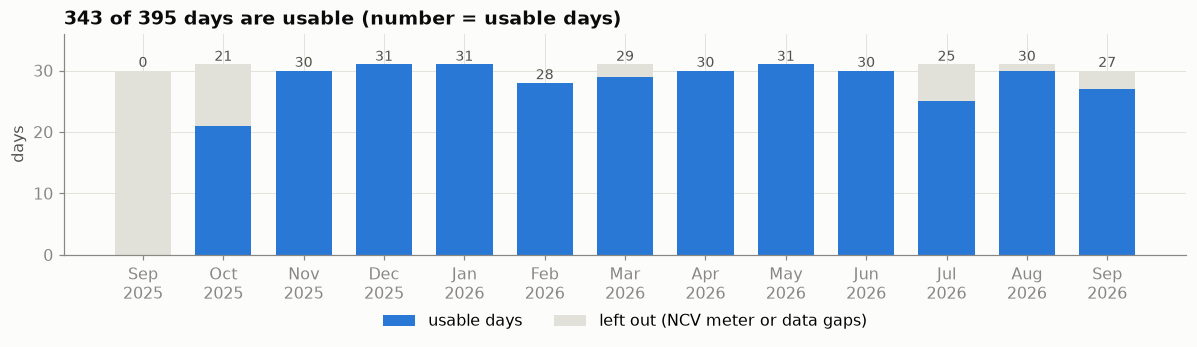

In [5]:
R.chart_coverage(D)

In [6]:
E.cleaning_table(D)

,found,action
check,,
"NCV outside 8,500–10,500 kcal/SCM (meter zero or glitch)","3,659 readings",removed; live: last valid NCV is used
NCV spike > 400 kcal/SCM away from its 2-hour median,159 readings,removed
day with less than 90% valid NCV,46 days,left out (no NCV is invented)
SAP draw doubled on a month-start day,3 days,halved (matches SAP exactly)
"short gaps in gas, air or boost",≤ 1 hour,filled by interpolation


**What we found**
- **Sep 2025 cannot be used:** the NCV meter read zero for the whole month. Every other month is almost fully usable.
- **3,659 NCV readings** were out of range (meter zero or glitch) and **159 were short spikes**. They were removed, and the same filter runs live: if the NCV is missing, the recommender uses the last valid reading.
- **46 days** had too little valid NCV and were left out. We never invent an NCV or take one from another source.
- **Draw was doubled on 3 month-start days** (1 Oct 2025, 1 Jun 2026, 1 Sep 2026), apparently two SAP entries added together. We halve it; the corrected values match SAP exactly. *Please check the month-start draw extract.*

**What it means for SFC:** 343 clean days remain, 286 of them in the baseline period. That is enough to measure effects as small as a few tenths of a percent.

## 1.3 A typical day in numbers
**How to read the table:** *typical* is the median day; *low day* and *high day* are P5 and P95, so 90% of days fall between them.

In [7]:
E.summary_table(D)

,meaning,unit,low day (P5),typical (median),high day (P95)
variable,,,,,
draw,glass pulled per day,t/day,51.3,58.5,61.6
SFC,energy per kg of glass,kcal/kg,"1,505.9","1,559.7","1,704.3"
total energy,gas heat + boost electricity,Gcal/day,86.4,91.2,94.3
gas heat,Σ NG × NCV,Gcal/day,73.7,76.8,79.7
electricity share,boost share of total energy,%,12.2,15.8,18.3
NCV,heat in one SCM of gas,kcal/SCM,"9,050","9,518","10,216"
NG flow,"melter gas, common header",SCM/15 min,77.3,82.9,90.7
secondary air,combustion air,SCM/15 min,959.2,"1,013.5","1,066.1"
air per Mcal,air per unit of gas heat,SCM/Mcal,1.240,1.267,1.295


**What we found**
- A typical day: **58.5 t of glass, 1,560 kcal/kg, 91 Gcal of energy**, of which about **84% is gas** and **16% electricity** (barrier + melter boost).
- **NCV ranges from 9,050 to 10,216 kcal/SCM** between a low and a high day: the same SCM of gas can carry about 13% more or less heat.
- The **crown is held very steady** (optical 1,573.7–1,575.3 °C between a low and a high day), while the **bottom (MB3) moves more** (1,318.7–1,323.4 °C).
- **Seeds** are 15 on a typical day and 21 on a high day, well below the spec of 30.

## 1.4 How the key variables are spread
**Why we look at it:** the shape of a distribution shows whether the furnace runs in one regime or several, and how much room there is between a good and a poor day.

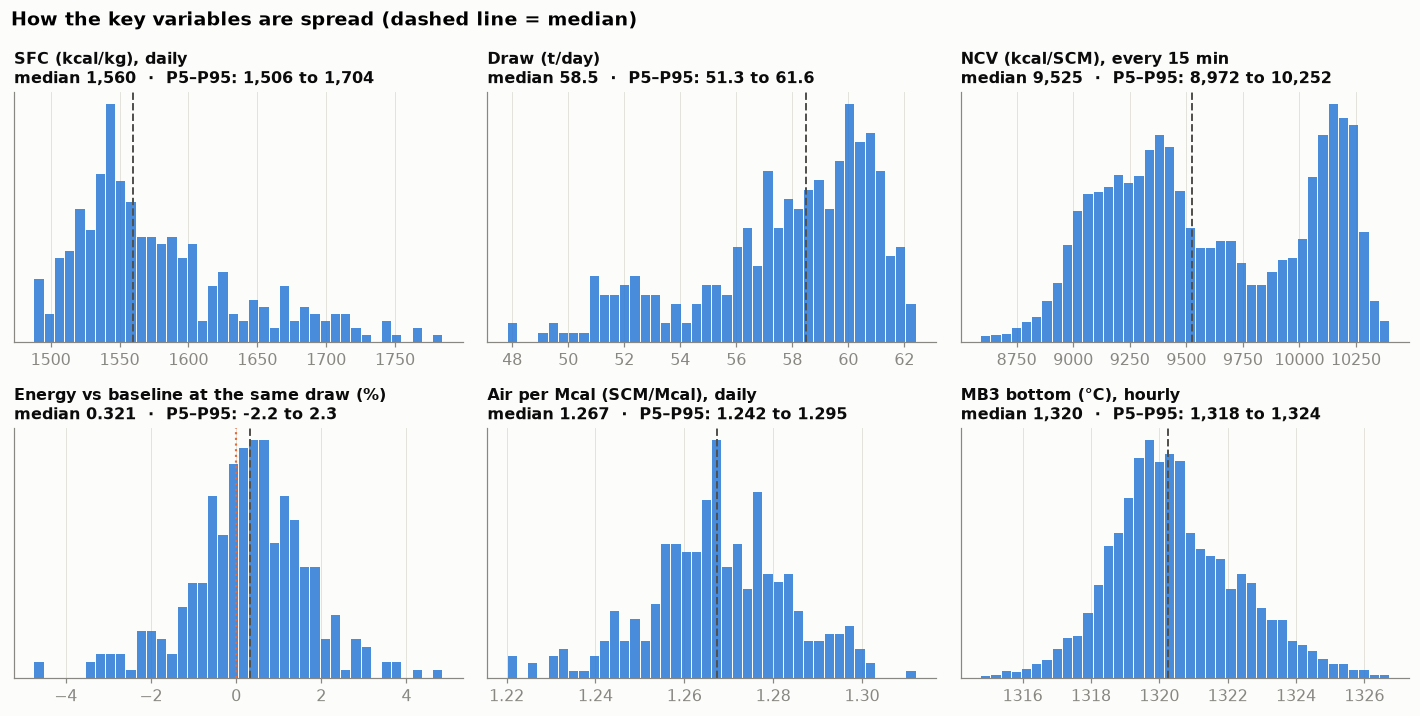

In [8]:
E.chart_distributions(D)

**What we found**
- **SFC** is mostly 1,500–1,600 kcal/kg, with a tail of high-SFC days. Section 3.2 shows these are low-draw days.
- **Draw** is mostly 56–62 t/day, with fewer low-draw days.
- **NCV has two peaks**, around 9,200 and around 10,100 kcal/SCM: the plant receives two clearly different gas qualities. The gas flow must follow them.
- **Energy at the same draw** (bottom left) spreads from about −2.2% to +2.3% between a good and a poor day. **This spread is the room that better operation can win back.**
- **MB3** is centred on 1,320 °C with a tail of hotter hours.

## 1.5 Thirteen months at a glance
**How to read the chart:** the line is the monthly median; the shaded band is the range of typical days in that month (P10 to P90).

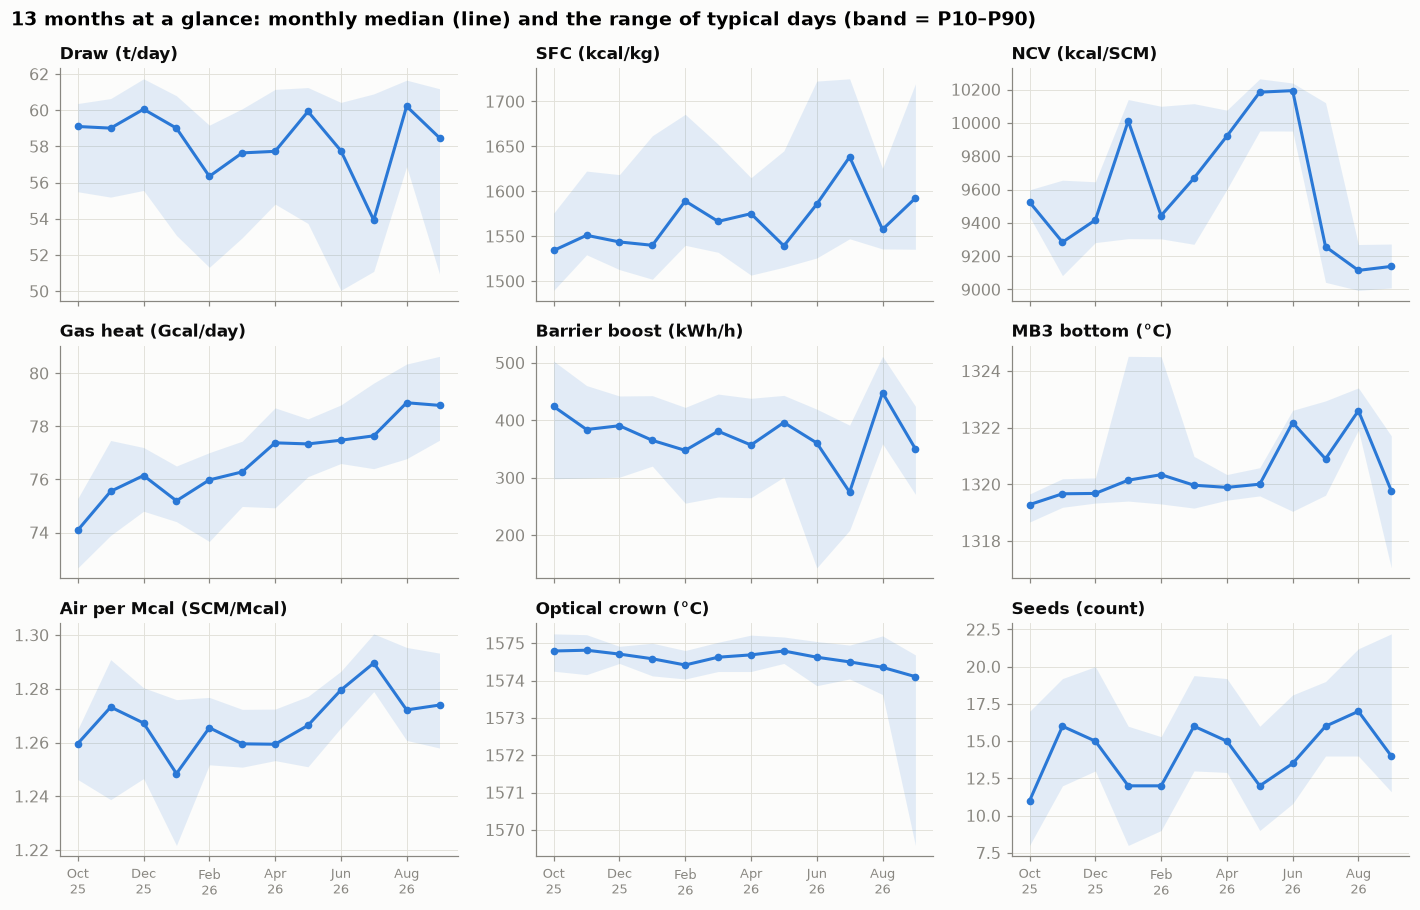

In [9]:
E.chart_monthly_grid(D)

**What we found**
- **Gas heat rises steadily**, from about 74 to about 79 Gcal/day over the year, while draw has no matching trend. This is the first sign of **furnace ageing** (section 3.3).
- **NCV changed in steps:** high (about 10,000–10,200) from Mar to Jun 2026, then low (about 9,100–9,250) from Jul 2026.
- **Barrier boost** was cut in Jul 2026 and raised sharply in Aug 2026, and **MB3 ran hotter** in Jun and Aug 2026 (about 1,322–1,323 °C) than in the rest of the year.
- **Air per Mcal** peaked in Jul 2026: more excess air than usual.
- The **optical crown** stays flat all year; **seeds** stay between about 11 and 17.

**What it means for SFC:** summer 2026 combined an ageing furnace, a hot bottom and more air than usual. These are exactly the levers the recommenders work on.

## 1.6 Inside one ordinary day
**Why we look at it:** daily averages hide how the furnace is actually run. This is 14 May 2026, an ordinary day (61.2 t, SFC 1,523 kcal/kg, energy at the same draw +0.4%).

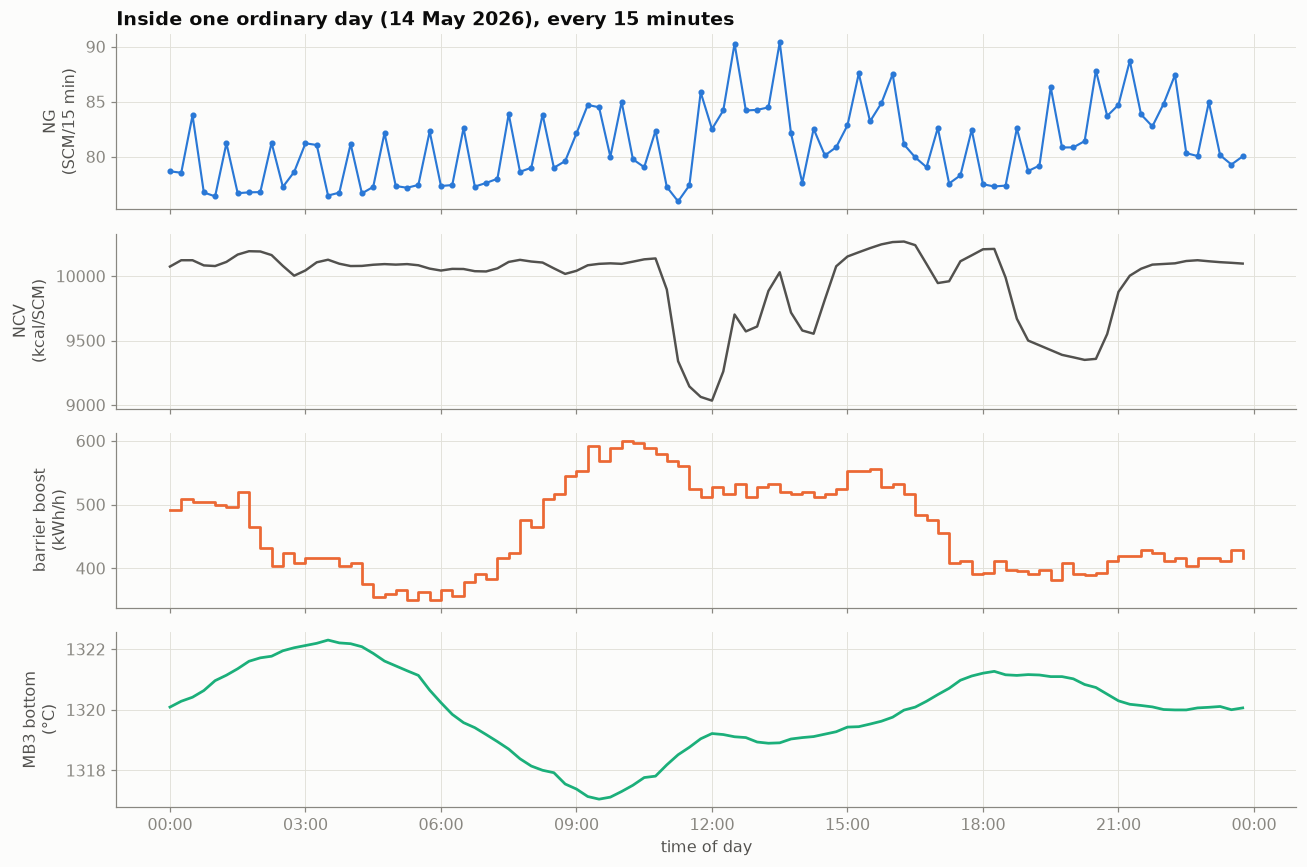

In [10]:
E.chart_one_day(D, '2026-05-14')

**What we found**
- **NG zig-zags** every few readings. This is the 20-minute reversal seen through a 15-minute record, not operator action.
- **NCV fell by about 10% at 11:00** (from about 10,100 to 9,050 kcal/SCM). NG was raised, but late and only part of the way, and it stayed higher after the NCV had recovered at about 14:00. Section 3.4 measures this across the whole year.
- **Barrier boost was raised from about 360 to 600 kWh/h** between 06:00 and 10:00 while MB3 fell to about 1,317 °C, and MB3 recovered a few hours later. Operators already use barrier boost to steer the bottom temperature, with a delay of several hours.

## 1.7 Correlation heat map: which signals move together
**Why we look at it:** before testing any cause, we check which daily values rise and fall together. This narrows down where to look.

**How to read the chart:** each square is the correlation between the row and the column, over 343 usable days. **Orange** = they rise together; **blue** = one rises when the other falls; **white** = no relationship. The darker the colour, the stronger the link.

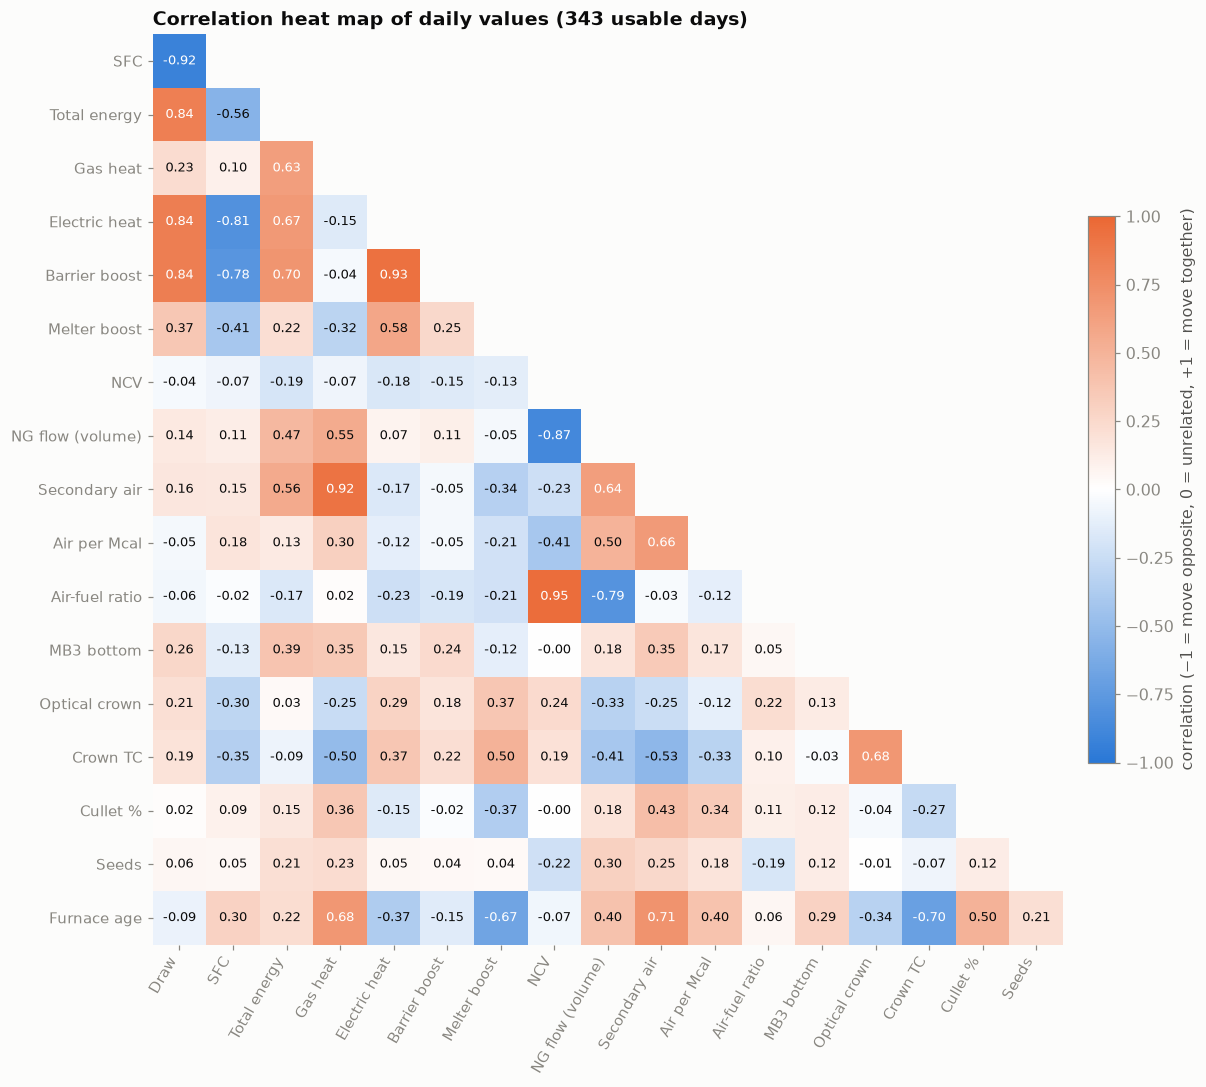

In [11]:
E.chart_heatmap(D)

In [12]:
E.top_pairs(D, 12)

,,correlation
Air-fuel ratio,NCV,0.95
Barrier boost,Electric heat,0.93
SFC,Draw,-0.92
Secondary air,Gas heat,0.92
NG flow (volume),NCV,-0.87
Electric heat,Draw,0.84
Barrier boost,Draw,0.84
Total energy,Draw,0.84
Electric heat,SFC,-0.81
Air-fuel ratio,NG flow (volume),-0.79


**What we found**

| Pair | Correlation | What it tells us |
|---|---|---|
| Draw and SFC | **−0.92** | The strongest link in the data. More glass per day means fewer kcal per kg (section 3.2) |
| Draw and barrier boost | **+0.84** | Operators raise barrier boost when draw rises. Boost is used as a heat source, not only to control the bottom |
| NCV and NG flow | **−0.87** | Over a day, operators do lower the gas flow when the gas is richer. Section 3.4 shows they do it late |
| NCV and AFR | **+0.95** | Richer gas needs more air per SCM, so the AFR follows NCV. Air follows heat, not gas volume |
| Secondary air and gas heat | **+0.92** | Same message: oxygen demand follows the heat burned |
| Furnace age and gas heat | **+0.68** | The furnace needs more gas as it ages (section 3.3) |
| Furnace age and crown TC | **−0.70** | The crown thermocouple reads slowly lower over the year, so it partly tracks ageing rather than firing |
| Furnace age and cullet % | **+0.50** | Cullet was higher later in the year. Any link between cullet and energy is borrowed from ageing; once ageing is allowed for, cullet has no significant effect |
| Optical crown and crown TC | **+0.68** | The two crown readings agree day to day |
| Seeds and every other signal | **≤ 0.30** | No operating signal is strongly tied to seeds: quality is not on a knife edge |

**A word of caution:** correlation shows association, not cause. Draw and barrier boost move together because operators adjust both, not because one causes the other. Every lever we use was therefore tested separately, with draw and ageing taken out (Parts 2 and 3).

## 1.8 Once draw is taken out: what goes with extra energy?
**Why we look at it:** draw dominates the heat map. To see what *operation* changes, we take each day's energy compared with the baseline at the same draw (the draw-adjusted %, section 2.3) and ask which signals move with it.

**How to read the chart:** orange bars go with **more** energy than expected for that draw; blue bars go with **less**.

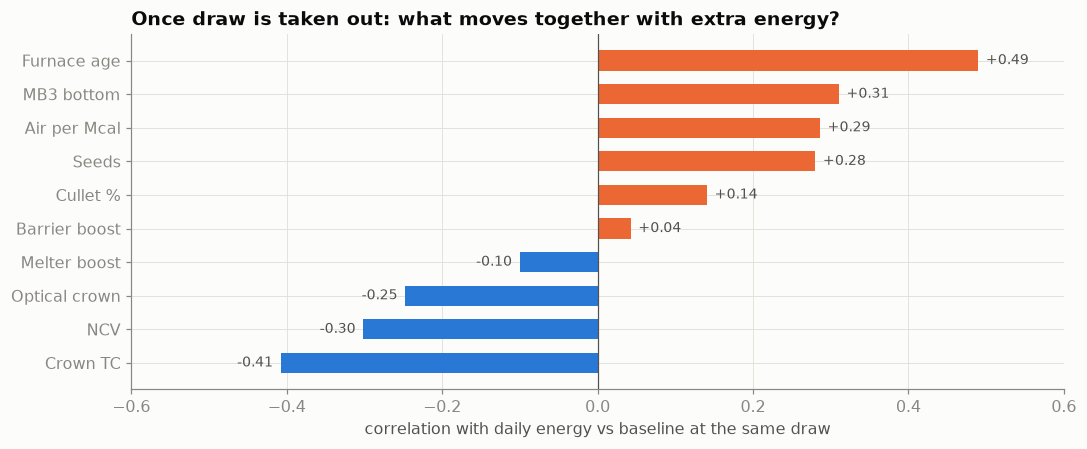

In [13]:
E.chart_draw_adjusted_drivers(D)

**What we found**
- **Furnace age (+0.49)** is the strongest link: the older the furnace, the more energy at the same draw.
- **A hotter bottom (MB3, +0.31)** and **more air per Mcal (+0.29)** go with extra energy. **Both are setpoints the operator controls**, through barrier boost and secondary air.
- **Seeds (+0.28):** days that use more energy also tend to have *more* seeds. Saving energy and good quality go together.
- **Crown TC (−0.41) and optical (−0.25)** look negative mainly because both read slightly lower as the furnace ages, so they carry the ageing signal. They are not a lever on their own.
- **Richer gas (NCV, −0.30)** goes with less energy. The recommender makes sure richer gas is fully used by cutting the flow straight away.

## 1.9 The key relationships in detail

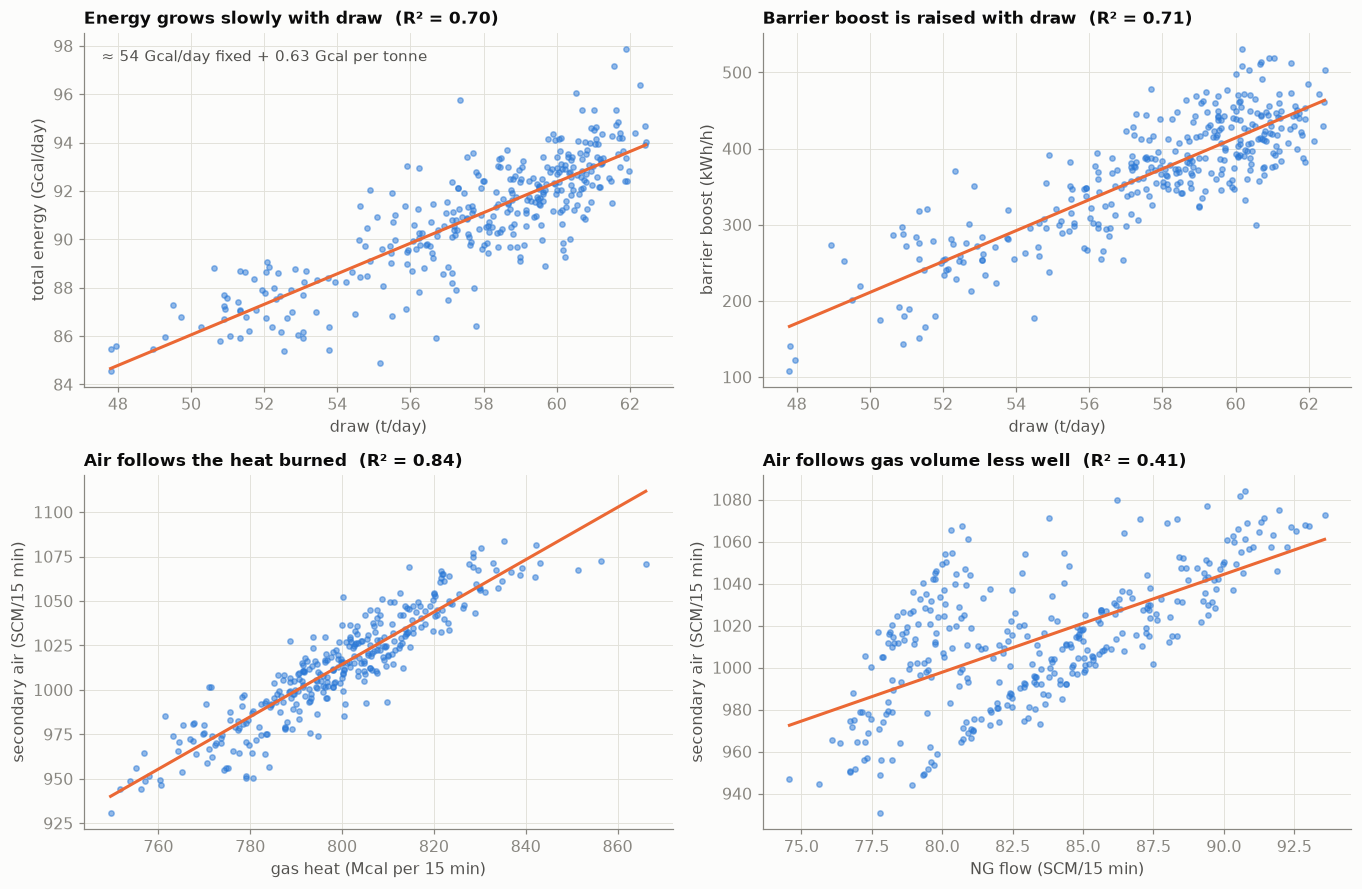

In [14]:
E.chart_key_relationships(D)

**What we found**
- **Top left:** energy rises only slowly with draw: about **54 Gcal/day is needed whatever the draw**, plus **0.63 Gcal per tonne**. Most of the furnace's energy is a fixed cost.
- **Top right:** barrier boost is raised with draw (R² 0.71). Part of the boost is used as a heat source.
- **Bottom row:** secondary air follows the **heat burned** (R² 0.84) much better than the **gas volume** (R² 0.41). This is why the recommender sets air from heat (air per Mcal × heat), not from a fixed AFR.

### EDA in one paragraph
The data is clean enough to measure small effects (343 usable days). Draw dominates SFC, the furnace slowly needs more energy as it ages, gas quality comes in two clear levels, and operators steer the bottom with barrier boost. Once draw is taken out, the days that use extra energy run a hotter bottom, more excess air and have slightly more seeds. These are the leads that Parts 2 and 3 test.

---
# Part 2. Features: what goes into the models
A **feature** is a value a model uses as an input. Raw measurements are rarely usable as they are: they must be cleaned, put on the right time scale and sometimes combined. This part shows which features we built, how, and why each one was kept or left out.

## 2.1 The features we built

In [15]:
E.feature_table()

,how we build it,from column,level,used for
feature,,,,
Gas heat,"Σ (NG × NCV) per 15 min, summed over the day","NG flow, NCV Meter",15 min → day,what the gas model predicts (Gcal/day)
Draw,SAP daily draw in tonnes; month-start doubling halved,Daily Draw,day,gas model input; fair yardstick
Barrier boost heat,Σ kWh × 860 ÷ 10⁶,BARRIER BOOSTER-52,15 min → day,gas model input (boost replaces part of the gas)
Melter boost heat,Σ kWh × 860 ÷ 10⁶,MELTER BOOSTER-51,15 min → day,gas model input
Furnace age,months since 1 Sep 2025,date,day,gas model input (ageing)
Latest valid NCV,range check + spike filter; last valid value if missing,NCV Meter,15 min,turns heat into NG flow: NG = heat ÷ NCV
Air per Mcal,secondary air ÷ gas heat,"Secondary air, NG, NCV",day,air target (efficient level of recent days)
Air-fuel ratio,secondary air ÷ NG,"Secondary air, NG",15 min,"operator setpoint, follows from the air target"
MB3 bottom temperature,hourly average,Thermocouple Melter Bottom 3,hour,barrier-boost controller input


**Three design choices worth knowing**
1. **Gas heat is built every 15 minutes** with that interval's NCV, then added up. Daily NG × average NCV would mix up rich-gas and lean-gas hours.
2. **Electric boost is converted to the same unit as gas** (Gcal, with 860 kcal per kWh), so gas and electricity can be compared and added.
3. **Furnace age is a feature in its own right**, so the gas target follows the furnace as it ages instead of chasing last year's state.

## 2.2 The fair yardstick: draw-adjusted energy
**Why we need it:** raw SFC rises whenever draw falls, even if nothing in the operation changed. To judge operation fairly, every day is compared with what the baseline furnace needed **at the same draw and cullet**:

`expected energy (Gcal/day) = 53.55 + 0.605 × draw (t) + 0.123 × cullet (%)`, fitted on the 286 usable baseline days

`draw-adjusted % = actual energy ÷ expected energy − 1`

**How to read the chart:** grey bars are raw SFC compared with the baseline; blue bars are the fair, draw-adjusted view. The −2% target applies to the blue bars.

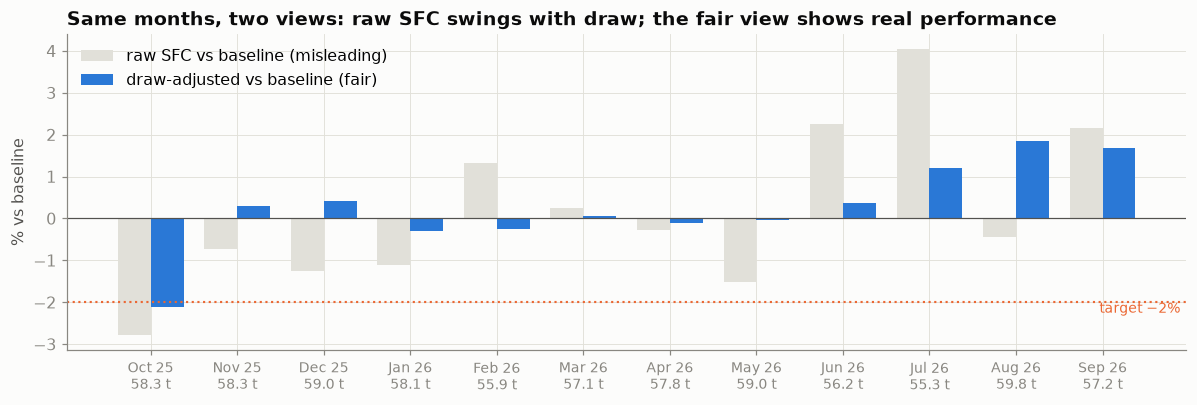

,draw (t/day),SFC,raw vs baseline %,draw-adjusted %
date,,,,
2025-10,58.29,1532.31,-2.79,-2.11
2025-11,58.33,1564.92,-0.72,0.29
2025-12,59.01,1556.53,-1.25,0.42
2026-01,58.11,1558.96,-1.10,-0.29
2026-02,55.88,1597.04,1.32,-0.26
2026-03,57.11,1580.34,0.26,0.06
2026-04,57.82,1571.85,-0.28,-0.11
2026-05,58.96,1552.58,-1.50,-0.03
2026-06,56.17,1611.94,2.26,0.37


In [16]:
R.chart_raw_vs_adjusted(D)

**What we found**
- **Jun and Jul 2026** look 2–4% worse on raw SFC, mostly because draw was low. Draw-adjusted, they were +0.4% and +1.2%.
- **Aug 2026** looks fine on raw SFC because draw was high, but draw-adjusted it was +1.8%.
- *Example:* on 29 Jul 2026 draw was only 49.7 t. Raw SFC (1,745 kcal/kg) looks 10.7% worse than the baseline, but the furnace used only 0.96% more energy than the baseline furnace would have at that draw.

**What it means for SFC:** this yardstick is used for every comparison in this notebook and for measuring the trial, so that changes in draw never hide or fake a saving.

## 2.3 How much each feature moves the gas the furnace needs
**How to read the chart:** each bar shows how much the daily gas need changes when that feature moves from a low day (P10) to a high day (P90), with the others held constant. Values come from the gas model fitted on all 343 usable days.

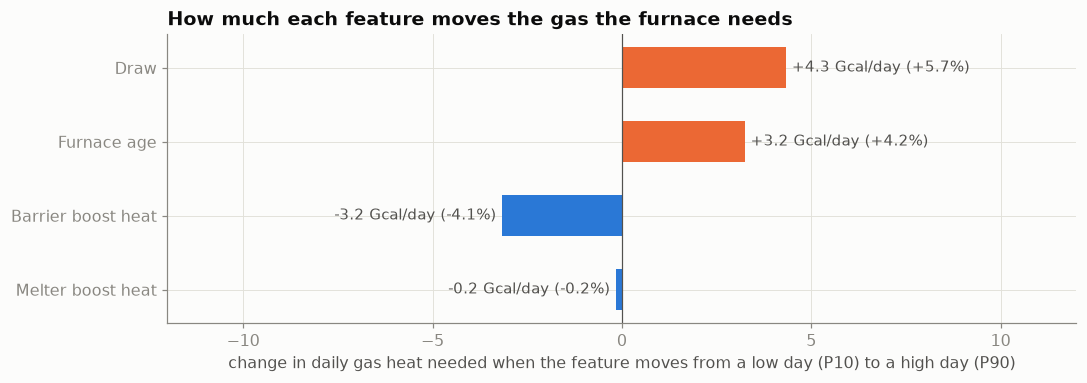

,low day (P10),high day (P90),unit,effect (Gcal/day),effect (% of gas)
feature,,,,,
Draw,52.33,61.09,t/day,4.34,5.66
Furnace age,2.44,11.72,months,3.25,4.23
Barrier boost heat,5.29,9.39,Gcal/day,-3.17,-4.13
Melter boost heat,6.28,7.89,Gcal/day,-0.16,-0.21


In [17]:
E.chart_feature_effects(D)

**What we found**
- **Draw** (52.3 → 61.1 t/day) needs **+4.3 Gcal/day** more gas (+5.7%), far less than the 17% rise in draw: the fixed heat loss again.
- **Furnace age** (2.4 → 11.7 months) needs **+3.2 Gcal/day** (+4.2%): ageing is almost as large as the whole draw range.
- **Barrier boost** (5.3 → 9.4 Gcal/day of electricity) saves only **3.2 Gcal/day of gas** for 4.1 Gcal of electricity added (section 3.6).
- **Melter boost** has almost no effect on the gas need, because it hardly changes.

## 2.4 Testing each feature
**Why we test:** a feature is kept only if it makes the model more accurate on days it has not seen. Each candidate was added to, or removed from, the model and tested walk-forward on two periods (Mar–May and Jun–Aug 2026).

**How to read the chart:** the bar is the change in prediction error compared with the final model. Above zero = worse. Bars marked * use same-day values that are **not known when the recommendation is made**, so their small gain cannot be used in practice.

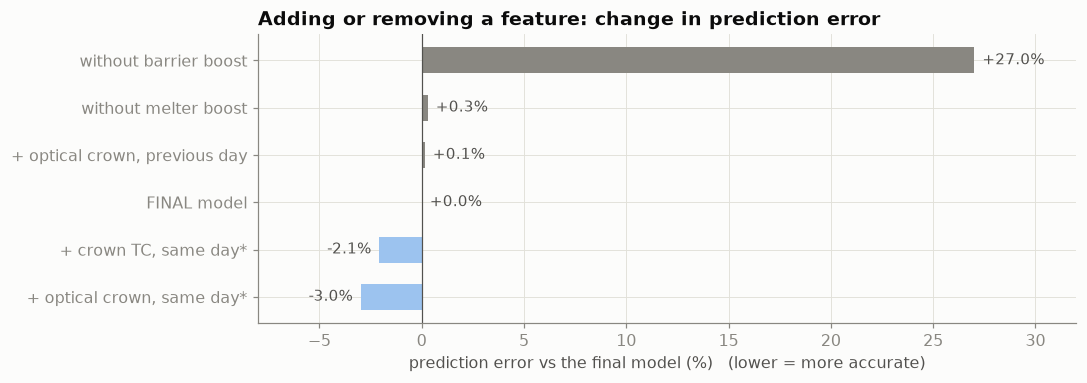

In [18]:
E.chart_feature_tests(D)

In [19]:
E.features_left_out()

,what the test showed,decision
candidate feature,,
Optical crown temperature (previous day),No gain in accuracy (0.344 vs 0.344); in Sep 2026 it read low and pushed the gas target the wrong way,kept as a safety check
Crown thermocouple MC3,"Small gain only with same-day values, which are not known when the recommendation is made",used to check the optical reading
Cullet %,16–20% in this period; no significant effect on energy once ageing is allowed for,kept in the fair yardstick only
MB3 in the gas model,"No reliable gain; MB3 is steered by barrier boost, not by gas",used by the boost controller
Melter boost in the boost controller,Changes in about 1% of hours; did not improve the MB3 forecast (0.540 → 0.537),the hourly MB3 feedback absorbs it


**What we found**
- **Barrier boost is essential:** without it the prediction error rises by **27%**.
- **Melter boost** adds little accuracy but is kept, because it is real heat.
- **Optical crown temperature from the previous day adds nothing** (+0.1%). In Sep 2026 it read low and would have pushed the gas target the wrong way, so it is used as a **safety check**, not as an input.
- Same-day crown readings help slightly, but only because they are measured after the operator has already reacted. They cannot be known in advance.

### Features in one paragraph
The final gas model uses four features, **draw, barrier boost heat, melter boost heat and furnace age**, plus the latest valid NCV to turn heat into gas flow. Air is set from heat, and barrier boost from the bottom temperature MB3. Crown temperature is watched as a guard-rail. Every comparison uses the draw-adjusted yardstick.

---
# Part 3. Insights: what we learned about your furnace
Twelve findings. Each one ends with **why it matters for SFC**.

## Insight 1. The baseline is confirmed from raw data

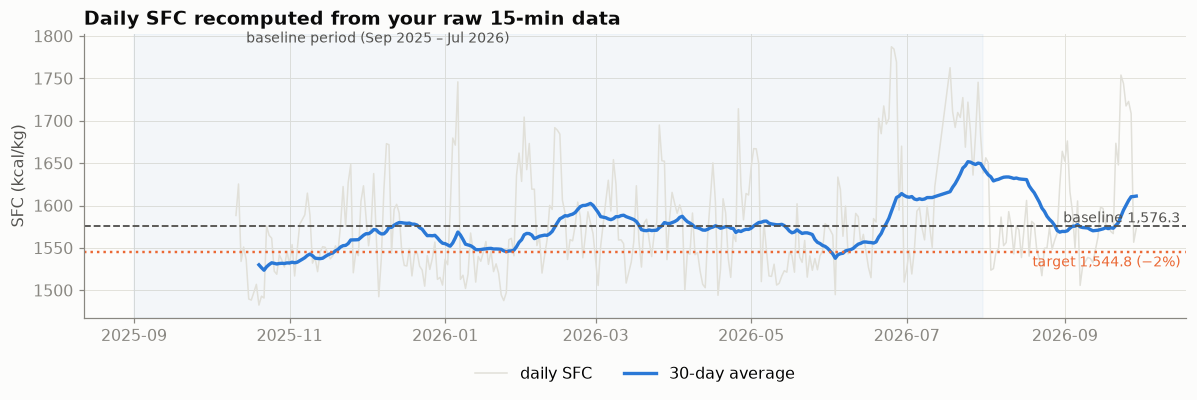

Baseline period, our average daily SFC: 1576.6 kcal/kg (your figure: 1,576.3) | target: 1,544.8


In [20]:
R.chart_baseline(D)
print('Baseline period, our average daily SFC: %.1f kcal/kg (your figure: 1,576.3) | target: 1,544.8' % D.base.sfc.mean())

**What we found:** recomputed from the raw 15-minute data, the baseline is **1,576.6 kcal/kg**, against your 1,576.3 (0.02% apart).

**Why it matters for SFC:** the data foundation matches your books, so **1,544.8 kcal/kg is the number to beat** and every saving below is measured on the same basis.

## Insight 2. Draw is the biggest driver of SFC
A furnace loses heat through the crown, walls, regenerators and flue **whatever it melts**. Only the heat for melting each extra tonne grows with draw. When draw falls, the fixed losses are spread over fewer kilograms and SFC rises.

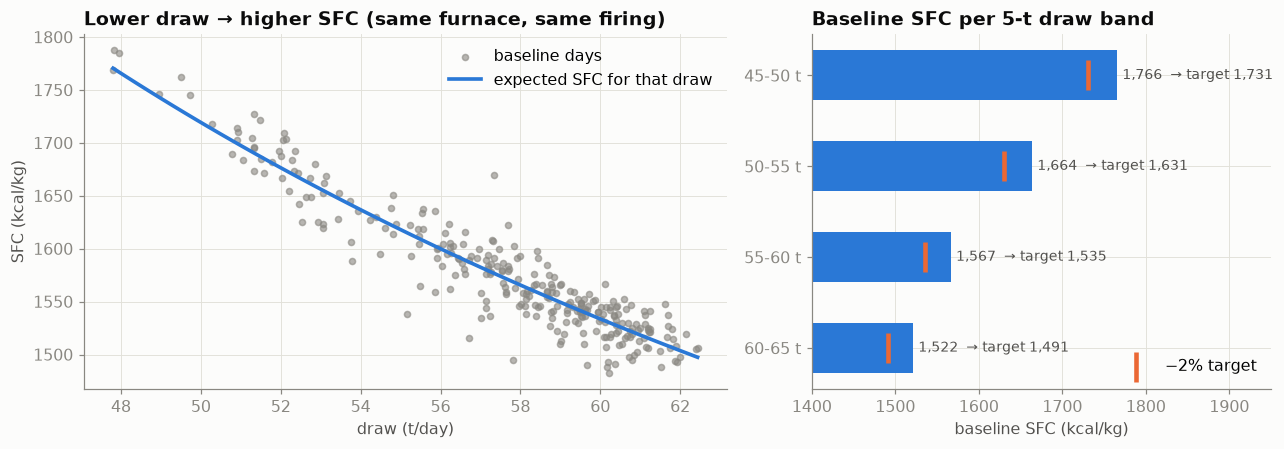

In [21]:
R.chart_draw(D)

**What we found**
- About **60% of the furnace's energy is fixed**, so **+1 t/day of draw lowers SFC by about 1%**.
- The four 5-t draw bands have very different baselines: from about **1,766 kcal/kg at 45–50 t** to **1,522 kcal/kg at 60–65 t**.

**Why it matters for SFC:** draw must be taken out before judging operation (section 2.2). Keeping draw at or above 58 t/day is itself one of the strongest SFC levers.

## Insight 3. Furnace ageing is a slow, steady headwind

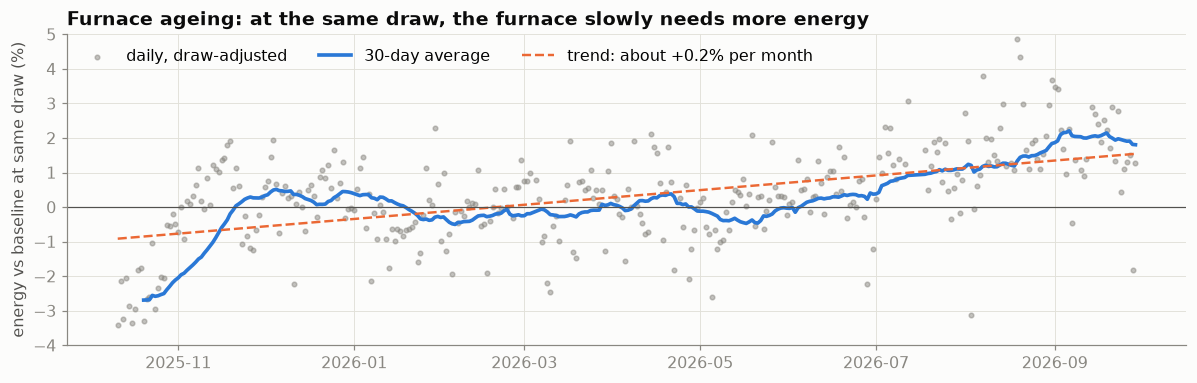

Ageing at the same draw: +0.19% energy per month


In [22]:
R.chart_ageing(D)
print('Ageing at the same draw: %+.2f%% energy per month' % (100 * D.mB.params.age_m / D.base.E_g.mean()))

**What we found:** at the same draw, energy rises by about **0.19% per month**. By summer 2026 the furnace used about **1.1% more energy than the baseline** at the same draw.

**Why it matters for SFC:** ageing is not caused by operators. The gas model includes furnace age, so its targets stay realistic as the furnace ages, and the savings it finds come on top of the ageing drift. Higher draw and regenerator maintenance recover the drift itself.

## Insight 4. Gas quality changes faster than the gas flow follows
When NCV rises, each SCM carries more heat, so the gas flow should fall by the same proportion to keep the heat steady. The first chart shows one day; the second measures the response over the whole year.

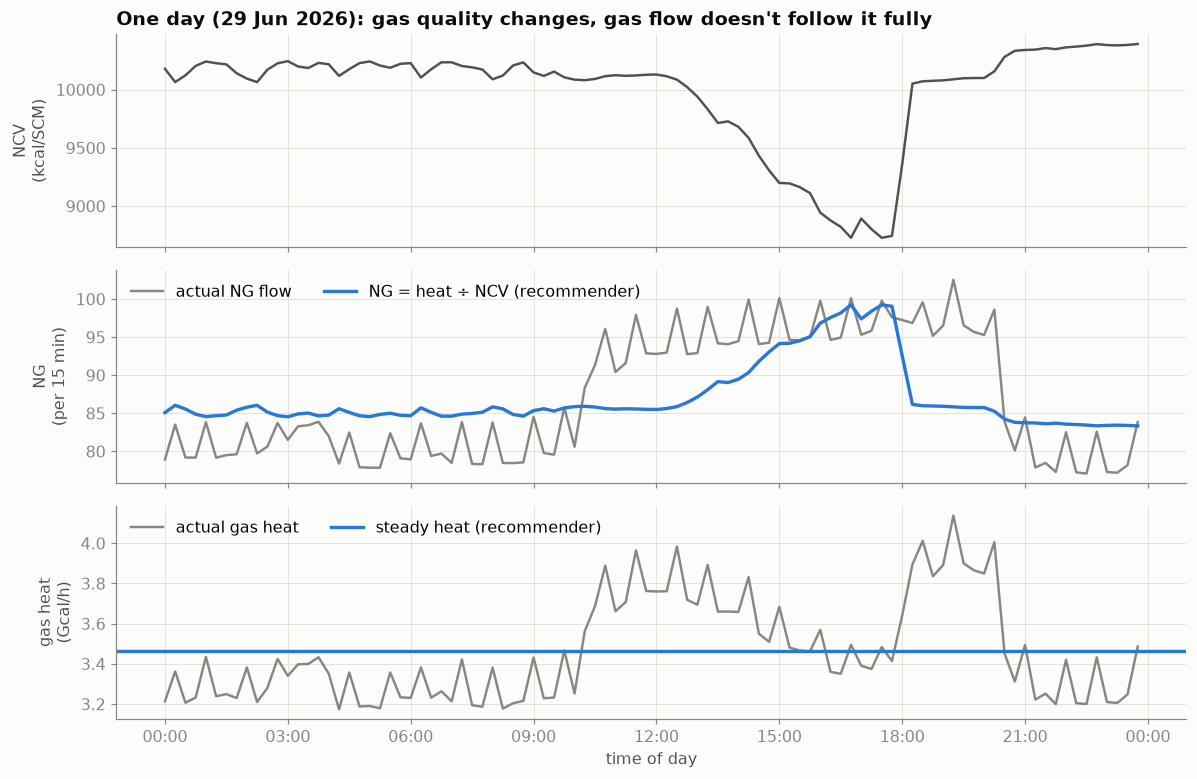

In [23]:
R.chart_ncv_day(D, '2026-06-29')

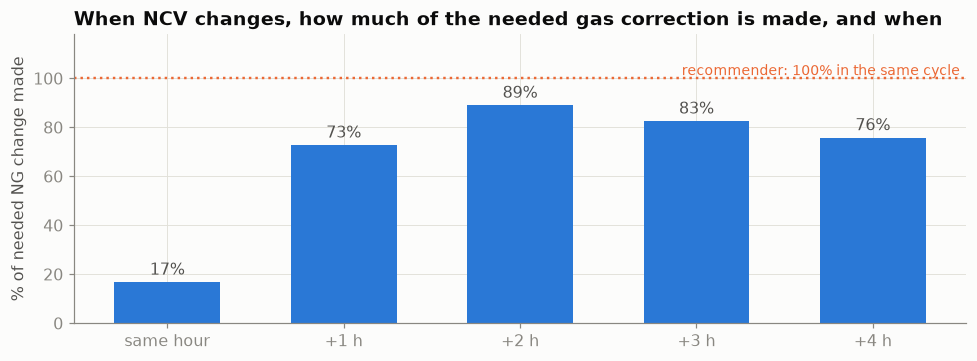

In [24]:
R.chart_ncv_lag(D)

**What we found:** after an NCV change, only **17%** of the needed gas correction is made in the same hour, **73%** after one hour and **89%** after two hours. Meanwhile the furnace gets too much heat when NCV rises and too little when it falls, and the shortfall is usually made up later with extra margin.

**Why it matters for SFC:** the gas recommender sets **NG = heat needed ÷ latest NCV** in every reversal cycle. The correction is complete straight away and the heat delivered stays steady.

## Insight 5. Barrier boost is the handle for the bottom temperature
Barrier-boost electrodes heat the glass from below, where MB3 sits. Gas burns above the glass, and little of its heat reaches the bottom quickly.

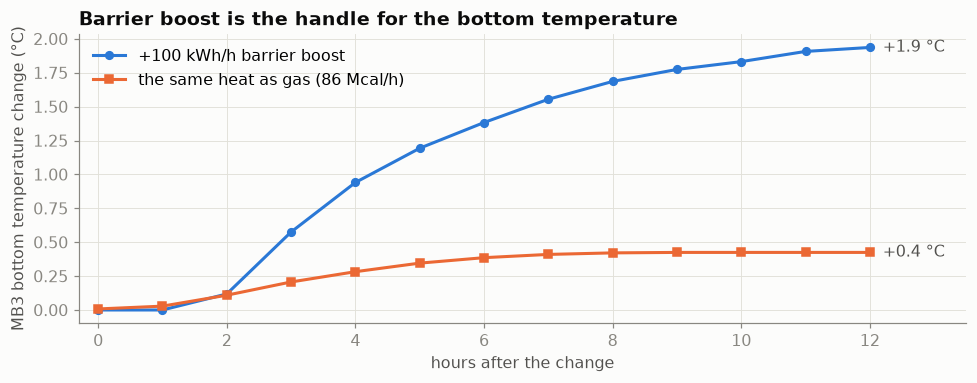

In [25]:
R.chart_boost_mb3(D)

**What we found:** **+100 kWh/h of barrier boost raises MB3 by about 1.9 °C** over 6–12 hours. The same heat delivered as gas moves MB3 by only about 0.4 °C. (Measured on 6,736 hours with a model that separates the furnace's response from operators' reactions.)

**Why it matters for SFC:** the bottom temperature should be steered with barrier boost, hour by hour, and the response takes several hours. That is what the barrier-boost recommender does.

## Insight 6. Extra barrier boost raises total energy

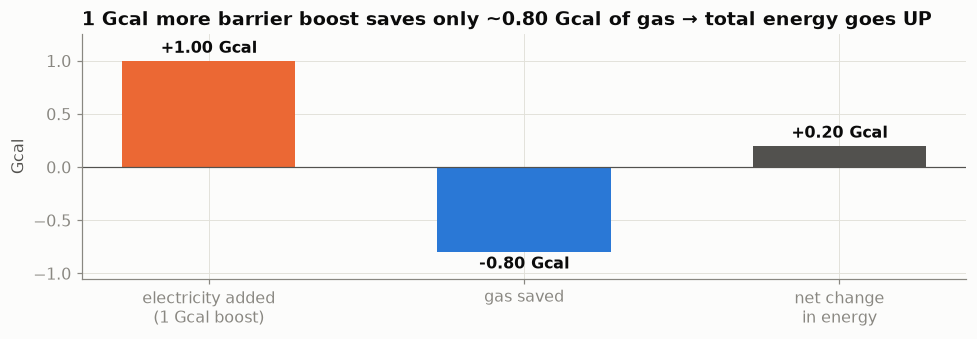

In [26]:
R.chart_boost_energy(D)

**What we found:** each extra Gcal of barrier boost saves only about **0.8 Gcal of gas** once ageing is allowed for, so **total energy goes up** when boost goes up. In Jun–Aug 2026 MB3 ran about 1.5 °C above its historical median: more boost was used than the glass needed.

**Why it matters for SFC:** the right policy is **the minimum boost that holds MB3 at its normal level**, not more. The boost recommender trims boost when the bottom is hot and adds it when the bottom is cold.

## Insight 7. Less excess air, less energy
Secondary air must supply the oxygen for combustion. Air beyond that is heated up and leaves through the regenerators and the flue, taking energy with it.

**How to read the chart:** days are split into five equal groups by air per Mcal; each point is the group's energy compared with what was expected for its draw and furnace age (with a 95% range).

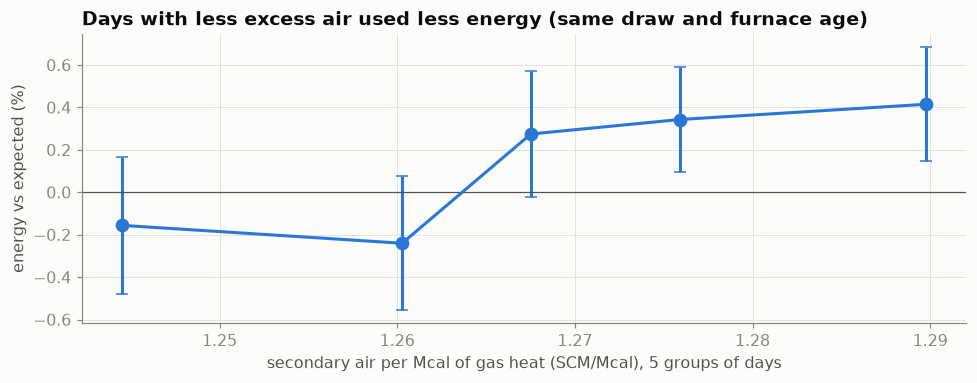

In [27]:
R.chart_air(D)

**What we found:** days with less air per Mcal used measurably less energy: about **0.13 Gcal/day less for every 0.01 SCM/Mcal less air**, within the range the furnace already runs at.

**Why it matters for SFC:** the recommender sets air as **efficient air per Mcal × heat**, using the efficient level of the last 45 days and never less than the furnace has already run at safely (there is no O₂ analyser).

## Insight 8. Glass quality has headroom

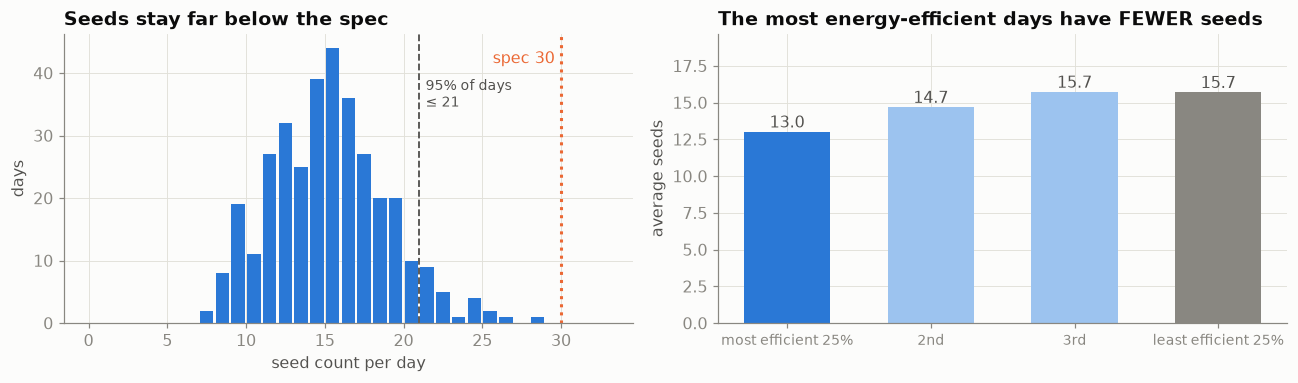

In [28]:
R.chart_seeds(D)

**What we found:** seeds stay far below the spec of 30 (95% of days ≤ 21, maximum 28). The most energy-efficient days have **fewer** seeds, not more.

**Why it matters for SFC:** saving energy inside the proven operating range does not put quality at risk. Seeds remain a daily guard-rail during the trial.

## Insight 9. The crown is held flat

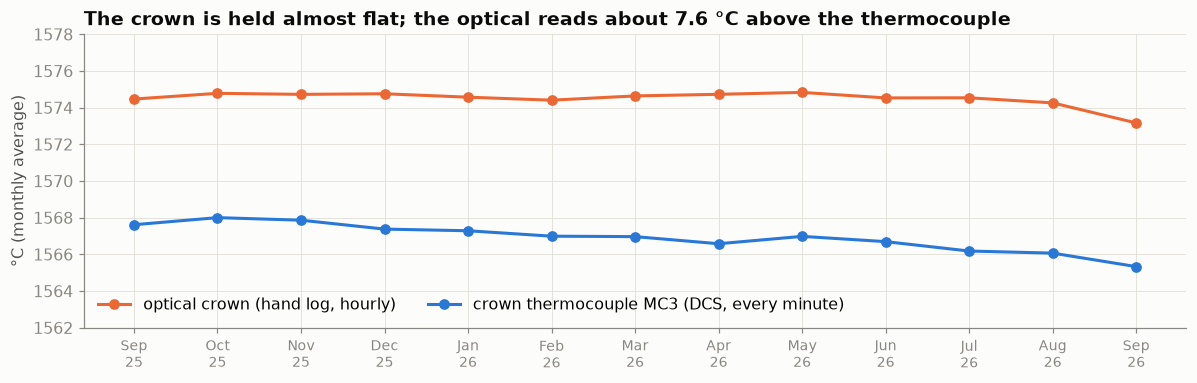

In [29]:
E.chart_crown(D)

**What we found:** the optical crown is held within about ±0.8 °C all year and reads about **7.6 °C above** the crown thermocouple. Both crown readings drift slightly lower over the year.

**Why it matters for SFC:** because the crown has always been held at the same level, history cannot show what a slightly lower crown setpoint would save. That is why a 1–2 °C lower crown setpoint is a **trial lever** (section 4.5), and why the recommender uses the crown reading as a safety check.

## Insight 10. The golden batch: your best days already exist
**How to read the chart:** every day's energy compared with the baseline at the same draw. The blue bars are the most efficient quarter of days.

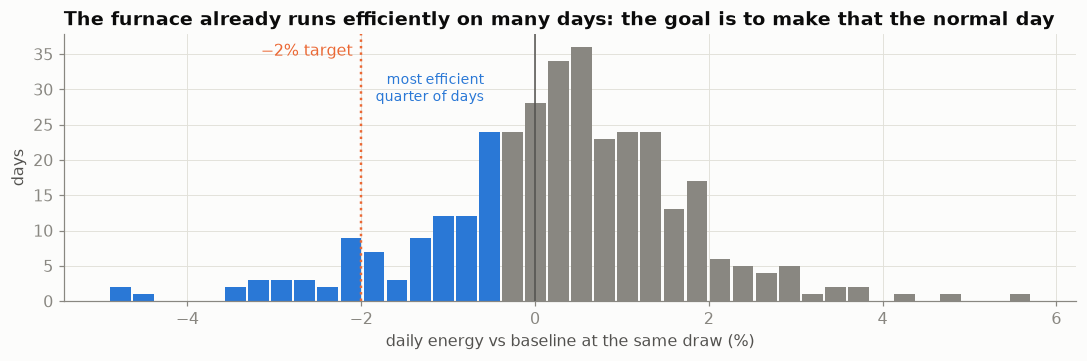

In [30]:
R.chart_efficient_spread(D)

In [31]:
R.best_vs_worst(D)

eff,most efficient 25%,least efficient 25%
energy vs baseline at same draw (%),-1.53,2.01
draw (t/day),57.62,57.96
air per Mcal,1.26,1.28
barrier boost (kWh/day),8750.29,8995.33
MB3 bottom temp (°C),1319.81,1321.06
optical crown temp (°C),1574.66,1574.15
seeds,13.01,15.70


**What we found**
- The most efficient quarter of days used **1.5% less** energy than the baseline at the same draw; the least efficient quarter used **2.0% more**: a **3.5-point gap at the same draw**.
- The efficient days ran **leaner air** (1.26 vs 1.28 SCM/Mcal), **less barrier boost** (about 245 kWh/day less), a **cooler bottom** (MB3 1,319.8 vs 1,321.1 °C), the **same crown temperature**, and had **fewer seeds** (13.0 vs 15.7).

**Why it matters for SFC:** the gas recommender's target is the gas the efficient quarter of comparable recent days needed. **The recommenders make the golden day the normal day.**

## Insight 11. Lowest and highest SFC days: what happened

In [32]:
lo, hi = E.lowest_highest(D)
print('Five lowest-SFC days'); display(lo)
print('Five highest-SFC days'); display(hi)

Five lowest-SFC days


,draw (t/day),SFC (kcal/kg),vs baseline at same draw (%),gas heat (Gcal/day),barrier boost (kWh/day),MB3 (°C),air per Mcal,seeds
date,,,,,,,,
20 Oct 2025,60.23,1482.55,-3.30,72.61,11332.8,1319.66,1.25,10.0
24 Jan 2026,61.51,1487.85,-1.32,74.64,12292.0,1324.33,1.26,14.0
17 Oct 2025,60.18,1488.45,-2.96,72.76,12208.3,1319.23,1.26,11.0
16 Oct 2025,59.68,1489.80,-3.36,73.46,10632.7,1318.63,1.25,11.0
22 Oct 2025,60.37,1490.93,-2.61,72.69,12072.0,1319.40,1.25,7.0


Five highest-SFC days


,draw (t/day),SFC (kcal/kg),vs baseline at same draw (%),gas heat (Gcal/day),barrier boost (kWh/day),MB3 (°C),air per Mcal,seeds
date,,,,,,,,
25 Jun 2026,47.82,1787.36,0.77,77.54,3381.4,1319.38,1.29,14.0
26 Jun 2026,47.96,1784.67,0.80,78.02,2952.0,1320.07,1.28,17.0
27 Jun 2026,47.80,1769.20,-0.29,77.48,2601.6,1320.63,1.28,12.0
18 Jul 2026,49.51,1762.65,1.66,76.82,4825.0,1318.29,1.31,12.0
23 Sep 2026,50.64,1753.98,2.79,77.59,6885.3,1317.10,1.28,11.0


**What we found**
- **Lowest SFC (1,483–1,491 kcal/kg):** Oct 2025 and Jan 2026, at **60–61.5 t/day**. Gas was only 72.6–74.6 Gcal/day, air per Mcal 1.25–1.26, and seeds 7–14.
- **Highest SFC (1,754–1,787 kcal/kg):** 25–27 Jun 2026 at **47.8 t/day**, the lowest draw of the year. Draw fell by about 17%, but gas stayed at about 77.5 Gcal/day, because the fixed heat loss does not fall with draw.

**Why it matters for SFC:** the raw extremes are mostly a draw story, which is why the trial is measured draw-adjusted.

## Insight 12. Same draw, different SFC: operation makes the gap

In [33]:
best, worst = E.same_draw_extremes(D)
print('Best days at the same draw'); display(best)
print('Worst days at the same draw'); display(worst)

Best days at the same draw


,draw (t/day),SFC (kcal/kg),vs baseline at same draw (%),gas heat (Gcal/day),barrier boost (kWh/day),MB3 (°C),seeds
date,,,,,,,
03 Jun 2026,57.81,1494.85,-4.91,72.15,9257.10,1322.42,12.0
23 Apr 2026,56.70,1515.26,-4.75,72.38,8415.50,1319.54,16.0
24 Feb 2026,55.17,1538.39,-4.54,72.48,7204.21,1319.77,9.0
11 Oct 2025,53.78,1588.32,-3.41,72.67,6749.30,1319.04,19.0


Worst days at the same draw


,draw (t/day),SFC (kcal/kg),vs baseline at same draw (%),gas heat (Gcal/day),barrier boost (kWh/day),MB3 (°C),seeds
date,,,,,,,
29 Jun 2026,57.34,1670.06,5.71,83.15,7345.5,1318.05,11.0
19 Aug 2026,61.90,1581.30,4.85,82.22,10866.6,1324.56,17.0
20 Aug 2026,61.57,1578.37,4.33,81.74,10623.4,1324.23,28.0
07 Aug 2026,60.54,1586.42,3.80,80.15,11147.5,1322.40,17.0


**What we found**
- At similar draw, the best and worst days differ by **up to 11 Gcal/day of gas** (72.2 vs 83.2 Gcal/day).
- On **19–20 Aug 2026**, MB3 was already about 4 °C above its median, yet barrier boost was raised to about 10,600–10,900 kWh/day and gas reached about 82 Gcal/day: both heat sources were pushed up at the same time. Seeds rose to 28 on 20 Aug.
- Replayed with the recommender (section 4.3), those two days come out at **1,507 and 1,511 kcal/kg instead of 1,581 and 1,578** (−4.7% and −4.3%).

**Why it matters for SFC:** this gap is controlled by setpoints, not by draw or ageing. It is the gap the recommenders close.

---
# Part 4. How these findings lower SFC

## 4.1 From finding to action

| What we found | What the recommender does | Effect on SFC |
|---|---|---|
| NCV changes are corrected late (17% in the same hour) | **NG = heat needed ÷ latest NCV**, every reversal cycle (ready by minute 15) | Heat stays on target: no over-firing after NCV rises, no catch-up after it falls |
| Efficient days already exist (3.5-point gap at the same draw) | Daily gas target = what the **efficient quarter of comparable recent days** needed (same draw, boost, furnace age) | Makes the golden day the normal day |
| Furnace ageing (+0.19% per month) | Furnace age is a model feature; the model is refit every day | Targets stay realistic as the furnace ages |
| Barrier boost steers MB3 but raises total energy | **Minimum boost that holds MB3 at 1,320.25 °C**, adjusted every hour | Less boost when the bottom is hot, more only when it is cold |
| Excess air carries heat away | **Air = efficient air per Mcal × heat**; AFR = air ÷ NG | Less heat lost through the regenerators and flue |
| Quality has headroom; efficient days have fewer seeds | Every setpoint stays inside the furnace's own P1–P99 history; seeds, MB3 and crown are guard-rails | Savings without quality risk |
| Draw dominates raw SFC | Every result is measured **draw-adjusted** and per band | Savings are real, not a draw effect |

## 4.2 What the operator receives

| | Gas recommender | Barrier-boost recommender |
|---|---|---|
| **When** | Every 20-minute reversal cycle, ready by minute 15 | Every hour |
| **Uses** | Latest NCV, draw, cullet, barrier and melter boost of the last hour; optical crown as a safety check | MB3 now, boost of the last hour |
| **Recommends** | **NG flow** (one value for both ports), **secondary air**, **AFR** | **Barrier boost** for the next hour |
| **Unit** | Same as your DCS / workbook column: the operator types the value directly | kWh/h |
| **Limits** | Inside the historical P1–P99 range | 114–610 kWh/h |

## 4.3 One recommendation, step by step
**19 Aug 2026, 10:00** (one of the worst days in Insight 12). **How to read the chart:** the grey bar is the furnace's own history (P1 to P99), the dark line its median, the orange dot what was actually run in that hour, and the green diamond the recommendation.

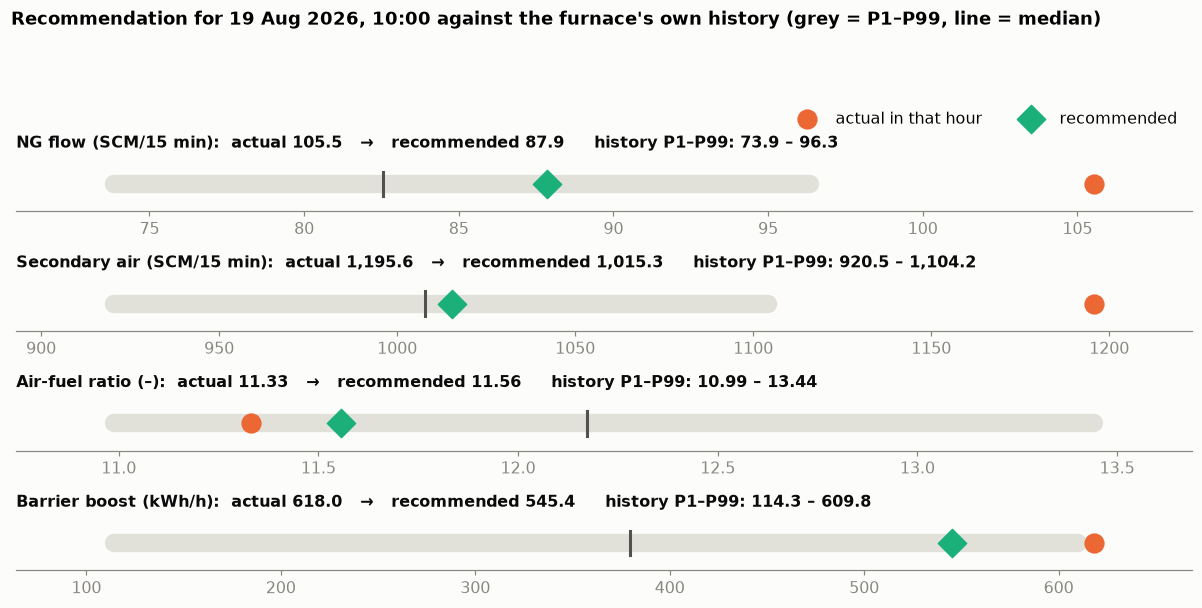

,input
date,2026-08-19
ncv,9117.0
draw_t,61.895
cullet_pct,19.0
optical_prev24h,1574.083333
bb_kwh_last_hour,563.0
mb_kwh_last_hour,305.6
mb3_now,1323.659116


In [34]:
E.chart_recommendation_example(D, '2026-08-19 10:00')

**What we found**
- NG (105.5 SCM/15 min) and secondary air (1,196) were running **above their historical P99**, and barrier boost (618 kWh/h) was at its maximum, while MB3 was already 1,323.7 °C.
- The recommendation brings **NG to 87.9**, **air to 1,015** and the **AFR to 11.56**, all inside history, and starts stepping barrier boost down (545 kWh/h) as MB3 returns towards 1,320 °C.
- Replayed over the whole day, SFC comes out at **1,507 instead of 1,581 kcal/kg (−4.7%)**.

## 4.4 What the recommendations achieved on your history
Each day was replayed **walk-forward**: the recommendation for a day uses only the days before it, exactly as in live use, and every setpoint stays inside the historical limits.

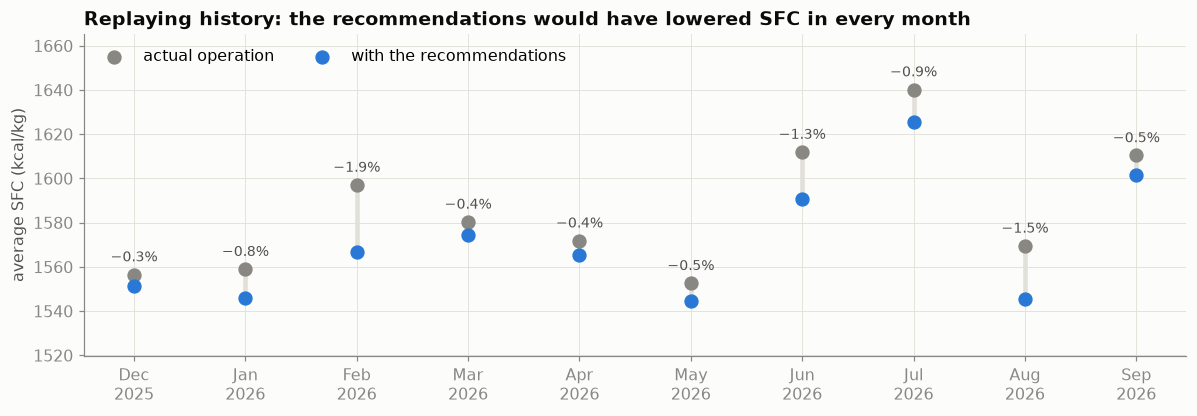

,actual,rec,days,saving
date,,,,
2025-12,1556.53,1551.31,31,0.34
2026-01,1558.96,1546.09,31,0.83
2026-02,1597.04,1566.98,28,1.88
2026-03,1580.34,1574.49,29,0.37
2026-04,1571.85,1565.38,30,0.41
2026-05,1552.58,1544.82,31,0.50
2026-06,1611.94,1590.87,30,1.31
2026-07,1640.20,1625.43,25,0.90
2026-08,1569.50,1545.32,30,1.54


In [35]:
R.chart_monthly_replay(D)

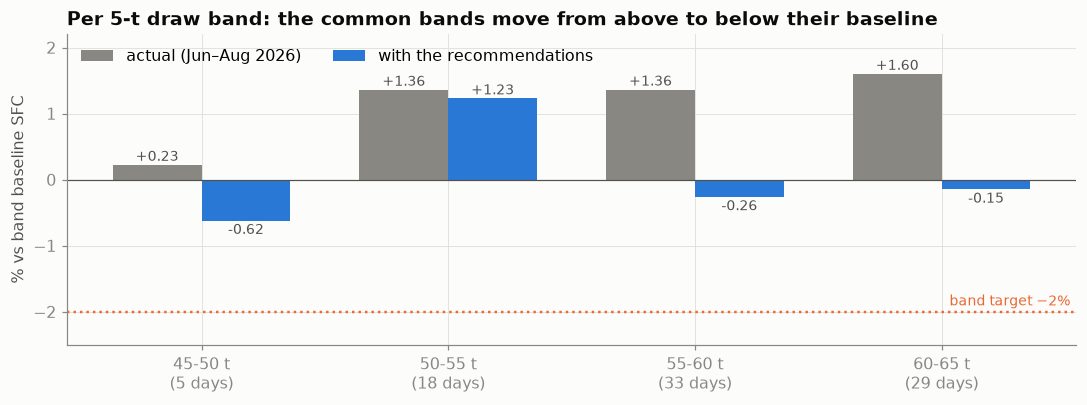

In [36]:
R.chart_bands(D)

**What we found**
- **SFC is lower in every month** of the replay (292 days, Dec 2025 – Sep 2026): **1,583 → 1,570 kcal/kg on average**, 0.3% to 1.9% lower each month.
- **Jun–Aug 2026:** **1,605 → 1,585 kcal/kg (−1.27%)**. Draw-adjusted, the furnace moves from **+1.14% above** the baseline to **−0.17% below** it.
- **Per band:** the two most common bands (55–60 t and 60–65 t) move from about 1.5% *above* their baseline to *below* it.
- **Sep 2026, a month the model had never seen:** the gas target stayed calibrated (26% of days beat it, 25% designed), and SFC was 0.55% lower. The bottom ran slightly cold that month, so the controller correctly added a little boost.

## 4.5 The path to 2%
The recommended setpoints deliver the proven part. Three trial levers, each a small step that stays inside the furnace's historical range, deliver the rest. All values are SFC reductions compared with today's operation at the same draw.

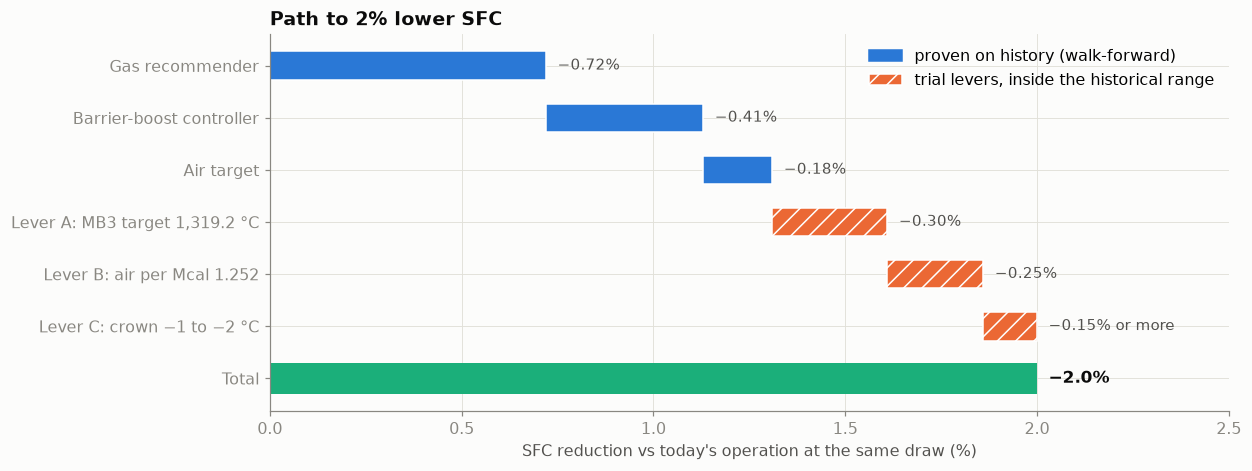

In [37]:
E.chart_path_today()

| Step | SFC reduction | Based on |
|---|---|---|
| Gas recommender (NG = heat ÷ NCV, efficient heat target) | 0.72% | Insights 2, 3, 4, 10; walk-forward replay |
| Barrier-boost controller (MB3 at 1,320.25 °C) | 0.41% | Insights 5, 6; walk-forward replay |
| Air target (efficient air per Mcal) | 0.18% | Insight 7 |
| **Recommended setpoints, proven on history** | **1.31%** | |
| Lever A: MB3 target lowered to 1,319.2 °C (historical P25) | about 0.30% | Insights 5, 6, 10 |
| Lever B: air per Mcal towards 1.252 (historical P25), with a portable O₂/CO check | about 0.25% | Insights 7, 10 |
| Lever C: optical crown setpoint 1 °C, then 2 °C lower | 0.15% or more | Insights 8, 9 |
| **Total** | **about 2%** | |

**Two further levers on top:** every extra tonne of draw lowers SFC by about 1% (Insight 2), and regenerator maintenance recovers the ageing drift (Insight 3).

## 4.6 How the saving will be proven
The trial runs in phases, one change at a time, with daily guard-rails: **seeds** (> 21 on two days or any day > 25), **MB3** (outside 1,317.6–1,323.9 °C for more than 3 hours) and **crown temperature** (optical below 1,570 °C).

| Phase | Weeks | What changes | Expected reduction |
|---|---|---|---|
| 0. Shadow mode | 1–2 | Recommendations calculated and logged, not applied; data feeds checked | 0% |
| 1. Gas + air | 3–6 | NG and secondary air set from the recommender every reversal cycle | about 0.9% |
| 2. + Barrier boost | 7–10 | Barrier boost from the controller | about 1.3% |
| 3. Trial levers | 11–14 | MB3 target, air per Mcal, crown setpoint, one at a time | about 2.0% |
| 4. Lock-in | after | Final settings become the standard; 30 days of measurement | 2% or more |

Day-to-day noise in the draw-adjusted energy is about 1.3%, so the average needs enough days to be reliable:

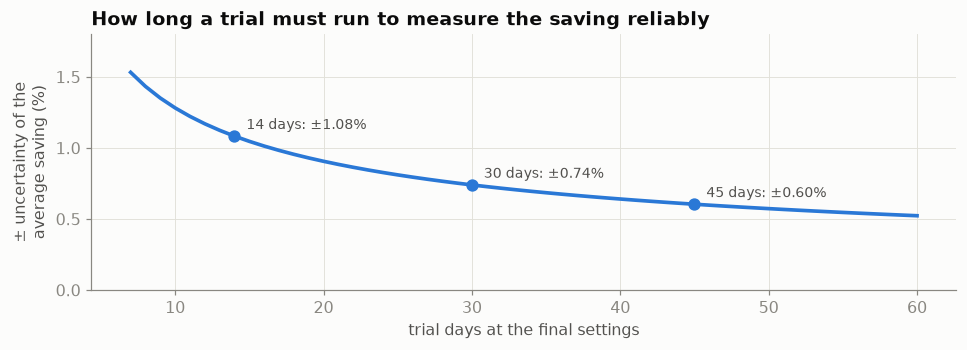

In [38]:
R.chart_mv_ci()

**30 trial days measure the saving to about ±0.74%** (95% confidence). Each phase therefore runs long enough to show its saving clearly.

---
# Summary

| Question | Answer |
|---|---|
| Is the data good enough? | **Yes.** 343 clean days, 37,920 fifteen-minute records; NCV glitches and draw doubling found and corrected |
| Is the baseline right? | **Yes.** 1,576.6 kcal/kg from raw data vs 1,576.3 stated. Target 1,544.8 |
| What drives SFC? | **Draw** (+1 t/day ≈ −1%), **furnace ageing** (+0.19% per month) and **how gas, air and boost are set** |
| What does the heat map show? | Draw dominates; boost follows draw; air follows heat; once draw is removed, a hotter bottom and more excess air go with extra energy |
| Which features matter? | Draw, barrier boost heat, melter boost heat and furnace age for gas; latest NCV for the gas flow; heat for air; MB3 for boost |
| Where is energy lost today? | Gas corrected late after NCV changes; more barrier boost than the bottom needs; more air than on the best days |
| Is quality at risk? | **No.** Seeds far below spec, and efficient days have fewer seeds |
| What do the recommendations deliver? | Lower SFC in **every month** of the replay; **−1.27%** in Jun–Aug 2026; draw-adjusted **+1.14% → −0.17%** |
| How do we reach 2%? | Recommended setpoints (**1.31%, proven**) + MB3 target, air and crown trial levers (**about 0.7%**) = **about 2% lower SFC** |

### Next steps
1. **October 2026 data** in the corrected format, for a fresh check on an unseen month.
2. **Official limits** for MB3, the crown band and electrode current, if tighter than the historical range.
3. A **portable O₂/CO analyser** for lever B.
4. Agree the **success yardstick** (draw-adjusted and per band) and the start date of the **shadow phase**.